<a href="https://colab.research.google.com/github/nickplas/Intro_to_ML_25-26/blob/main/challenges/challenge-one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge 1: The banknote-authentication data set problem

In [38]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.inspection import DecisionBoundaryDisplay

# fetch dataset
banknote_authentication = fetch_ucirepo(id=267)

# data (as pandas dataframes)
X = banknote_authentication.data.features
y = banknote_authentication.data.targets

# metadata
print(banknote_authentication.metadata)

# variable information
print(banknote_authentication.variables)


{'uci_id': 267, 'name': 'Banknote Authentication', 'repository_url': 'https://archive.ics.uci.edu/dataset/267/banknote+authentication', 'data_url': 'https://archive.ics.uci.edu/static/public/267/data.csv', 'abstract': 'Data were extracted from images that were taken for the evaluation of an authentication procedure for banknotes.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1372, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Fri Feb 16 2024', 'dataset_doi': '10.24432/C55P57', 'creators': ['Volker Lohweg'], 'intro_paper': None, 'additional_info': {'summary': 'Data were extracted from images that were taken from genuine and forged banknote-like specimens.  For digitization, an industrial camera usually used for print inspection was used. The final im

We will perform a nearly realistic analysis of the data set bank note authentication that can be downloaded from https://archive.ics.uci.edu/dataset/267/banknote+authentication

## Data set description

Data were extracted from images that were taken from genuine and forged banknote-like specimens. For digitization, an industrial camera usually used for print inspection was used. The final images have 400x 400 pixels. Due to the object lens and distance to the investigated object gray-scale pictures with a resolution of about 660 dpi were gained. Wavelet Transform tool were used to extract features from images.
These features are:
1. variance of Wavelet Transformed image (continuous) 
2. skewness of Wavelet Transformed image (continuous) 
3. curtosis of Wavelet Transformed image (continuous) 
4. entropy of image (continuous) 
5. class (integer)

## Task description
We have a binary classification problem. The assignment can be divided in several parts:
    
    1. Load the data and pretreatment.
    2. Data exploring by Unsupervised Learning techniques.
    3. Construction of several models of Supervised Learning.

### 1. Data pretreatment

Load the data and look at it: It is needed some kind of scaling? Why? Are the data points sorted in the original data set? Can it generate problems? How can this be solved?

In [39]:
X

,variance,skewness,curtosis,entropy
0,3.62160,8.66610,-2.8073,-0.44699
1,4.54590,8.16740,-2.4586,-1.46210
2,3.86600,-2.63830,1.9242,0.10645
3,3.45660,9.52280,-4.0112,-3.59440
4,0.32924,-4.45520,4.5718,-0.98880
...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949
1368,-1.38870,-4.87730,6.4774,0.34179
1369,-3.75030,-13.45860,17.5932,-2.77710
1370,-3.56370,-8.38270,12.3930,-1.28230


In [40]:
print(np.unique(y))

[0 1]


In [41]:
# 1. Split with test_size=372 e stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=372, # 372 test elements
    random_state=0,
    stratify=y
)
# 2. Scaling
scaler = StandardScaler().fit(X_train)
X_test = scaler.transform(X_test)

X_train = scaler.transform(X_train)

# Dimension check
print(f"Dimension of X_train: {X_train.shape}")
print(f"Dimension of X_test: {X_test.shape}")
print(f"Stratification ratio: {y_test['class'].value_counts(normalize=True)}")

Dimension of X_train: (1000, 4)
Dimension of X_test: (372, 4)
Stratification ratio: class
0    0.556452
1    0.443548
Name: proportion, dtype: float64


In [42]:
df_view = pd.DataFrame(X_train, columns=X.columns)
y_train.reset_index(drop=True)
df_view["Class"] = y_train["class"].values
df_view.head()

,variance,skewness,curtosis,entropy,Class
0,0.401491,-0.172651,-0.867978,0.956758,1
1,-1.054252,-0.360276,0.015280,1.144385,1
2,-1.846200,-1.378410,2.315310,0.026305,1
3,-1.004095,-0.396031,0.062675,0.341936,1
4,0.420678,0.240830,0.337587,0.595469,0


### Data Preprocessing Report: Splitting and Scaling
To ensure a robust evaluation, I started by dividing the dataset using a Stratified Train-Test Split. This method was chosen to maintain the original proportion of classes (Genuine vs. Forged) in both subsets, preventing any representational bias during the training phase.

Following the split, I applied Data Scaling (e.g., StandardScaler) to normalize the feature range. Crucially, this scaling was performed after the split to prevent Data Leakage:

The scaler was fitted only on the Training Set to learn the parameters (mean and standard deviation).

These parameters were then used to transform the Test Set.

This strict separation ensures that the model has zero knowledge of the test data's statistical properties during training, guaranteeing that our final evaluation metrics reflect true performance on unseen data.

### 2. Unsupervised Learning

Use PCA and plot the two first components colouring according with the class. Are the classes linearly separable in this projection? What happens when I applied k-means with two classes in this space? And if I use all the coordinates? Try also t-SNE for projection and DBSCAN for the clustering and comment on the results.

In [43]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Printing original dimensions and after PCA dimensions
print(f"Original dimension: {X_train.shape}")
print(f"Dimension after PCA: {X_train_pca.shape}")

Original dimension: (1000, 4)
Dimension after PCA: (1000, 2)


In [44]:
# Re-building pandas data frame after PCA
df_pca = pd.DataFrame(data = X_train_pca, columns=['PC1', 'PC2'])
y_train.reset_index(drop=True)
df_pca["Class"] = y_train["class"].values
df_pca.head()

,PC1,PC2,Class
0,0.150207,1.050286,1
1,-0.963090,-0.043541,1
2,-2.784470,-1.633940,1
3,-0.687054,-0.524171,1
4,-0.176326,0.635141,0


Text(0, 0.5, 'Principale component 2')

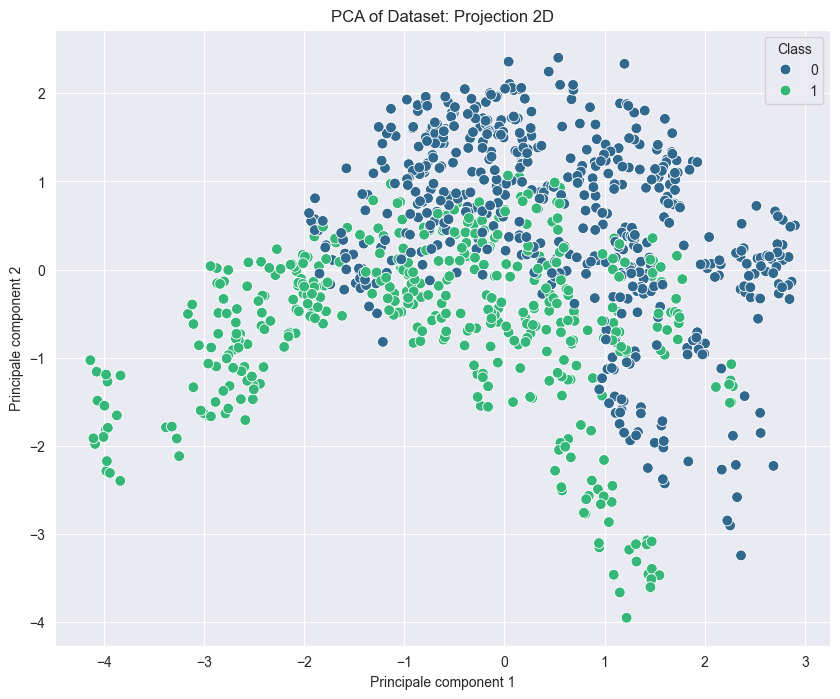

In [45]:
# Plotting the data to see clustering based on the two PCs
plt.figure(figsize=(10,8))
sns.scatterplot(x='PC1', y='PC2', hue='Class', data=df_pca, palette='viridis', s=60)
plt.title('PCA of Dataset: Projection 2D')
plt.xlabel('Principale component 1')
plt.ylabel('Principale component 2')

In [46]:
# Printing the variance of the two PCs components, inorder to
# determinate the total amount of maintained information
variance = pca.explained_variance_ratio_

print(f"PC1 explains: {variance[0]*100:.2f}% of variance")
print(f"PC2 explains: {variance[1]*100:.2f}% of variance")
print(f"Total amount of maintained information: {sum(variance)*100:.2f}%")

PC1 explains: 54.86% of variance
PC2 explains: 31.81% of variance
Total amount of maintained information: 86.67%


In [47]:
# How many PCs do we need for maintain the 95% of information?
pca_95 = PCA(n_components=0.95)
X_train_pca_95 = pca_95.fit_transform(X_train)

print(f"Number of components required for 95% variance: {pca_95.n_components_}")

Number of components required for 95% variance: 3


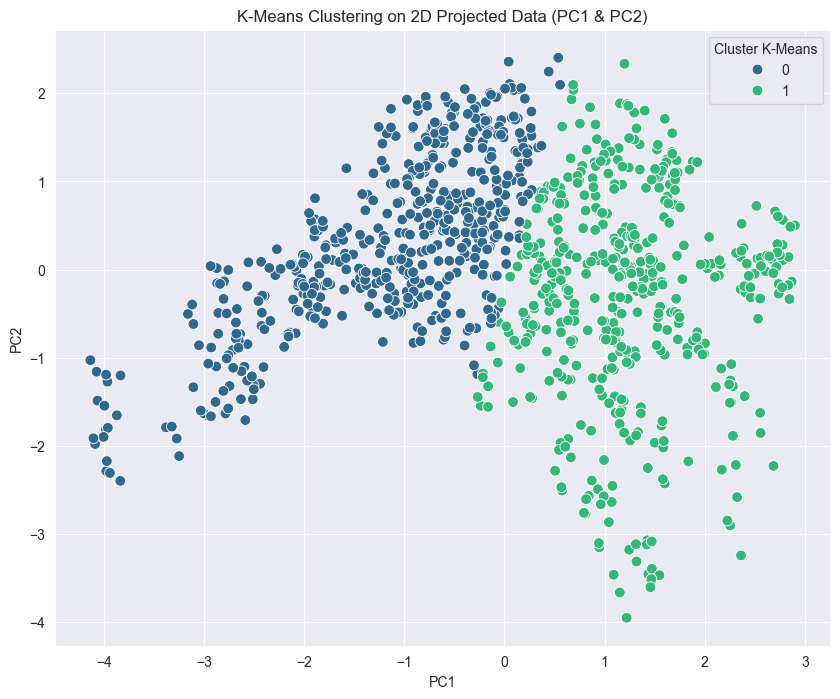

In [48]:
kmeans_2d = KMeans(n_clusters=2, random_state=0, n_init=10) # n_init=10 for reproducibility in sklearn
cluster_labels_2d = kmeans_2d.fit_predict(X_train_pca)

# Add cluster labels to DataFrame PCA
df_pca['KMeans_Cluster PCA'] = cluster_labels_2d

# Plot of K-Means results
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster PCA', data=df_pca, palette='viridis', s=60)
plt.title('K-Means Clustering on 2D Projected Data (PC1 & PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster K-Means')

In [49]:
contingency_matrix = pd.crosstab(df_pca['Class'],df_pca['KMeans_Cluster PCA'])

print(contingency_matrix)

KMeans_Cluster PCA    0    1
Class                       
0                   258  297
1                   266  179


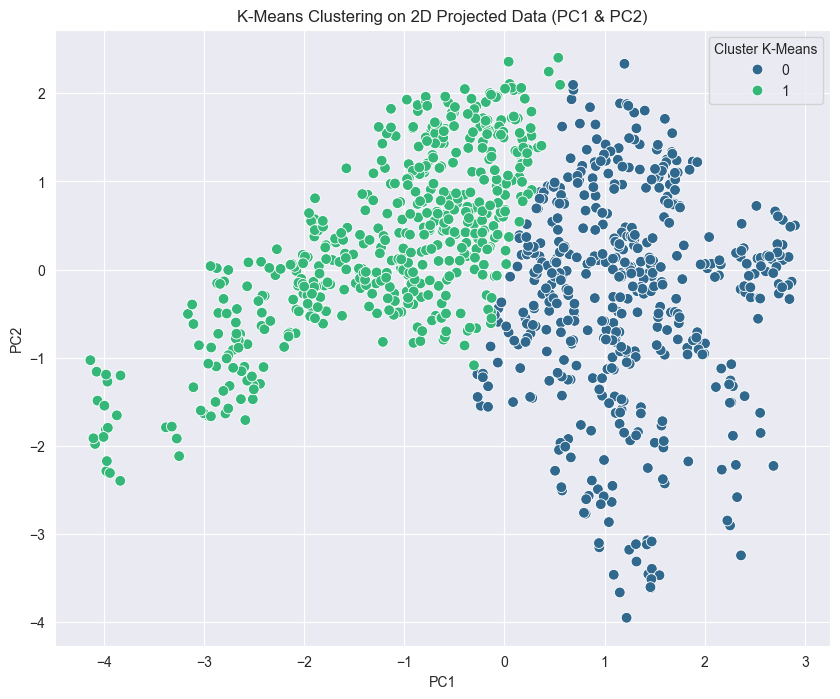

In [50]:
kmeans_4d = KMeans(n_clusters=2, random_state=0, n_init=10) # n_init=10 for reproducibility in sklearn
cluster_labels_4d = kmeans_4d.fit_predict(X_train)

# Save data of KMeans Cluster
df_pca['KMeans_Cluster'] = cluster_labels_4d


# Plot of K-Means results
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=df_pca, palette='viridis', s=60)
plt.title('K-Means Clustering on 2D Projected Data (PC1 & PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster K-Means')


In [51]:
# Make contingency matrix
contingency_matrix_4 = pd.crosstab(df_pca['Class'],df_pca['KMeans_Cluster'])


print(contingency_matrix_4)

KMeans_Cluster    0    1
Class                   
0               299  256
1               182  263


### Analysis of PCA and K-Means Clustering
In this phase, I utilized Principal Component Analysis (PCA) to reduce the dimensionality of the Banknote Authentication dataset and visualize the feature space. While PCA helped project the data into 2D, it revealed that the boundary between genuine and forged banknotes is complex and non-linear.Subsequently, I applied the K-Means algorithm (with $k=2$) to both the PCA-reduced data and the full 4-dimensional dataset. The contingency analysis showed that K-Means failed to separate the classes effectively. The resulting clusters were highly mixed (approximately 50% purity in the worst cases), indicating that the algorithm's assumption of spherical, equidistant clusters does not align with the actual geometric distribution of this dataset.

In [52]:
tsne = TSNE(n_components=2, random_state=42) # for reproducibility
X_train_tsne = tsne.fit_transform(X_train)

# Printing original dimensions and after t-SNE dimensions
print(f"Original dimension: {X_train.shape}")
print(f"Dimension after t-SNE: {X_train_tsne.shape}")

Original dimension: (1000, 4)
Dimension after t-SNE: (1000, 2)


In [53]:
# Re-building pandas DF
df_tsne = pd.DataFrame(data = X_train_tsne, columns=['t-SNE dimension 1', 't-SNE dimension 2'])

y_train.reset_index(drop=True)
df_tsne["Class"] = y_train["class"].values
df_tsne.head()

,t-SNE dimension 1,t-SNE dimension 2,Class
0,-3.550730,-9.346871,1
1,-16.109365,-25.195679,1
2,-44.328636,-6.981750,1
3,-10.046705,-24.321800,1
4,-0.498704,16.654676,0


Text(0, 0.5, 't-SNE dimension 2')

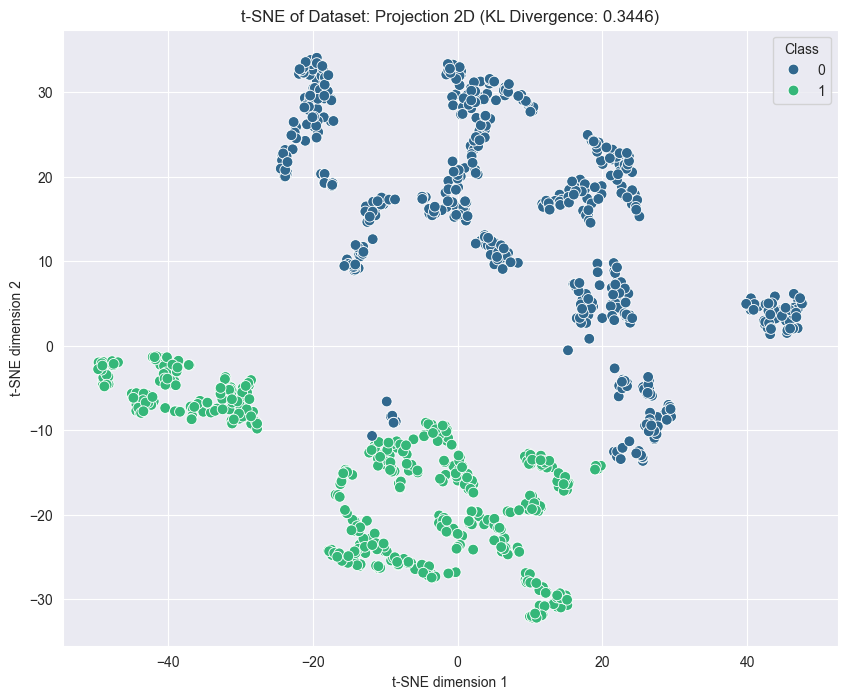

In [54]:
# Plotting the data to see clustering
plt.figure(figsize=(10,8))
sns.scatterplot(x='t-SNE dimension 1', y='t-SNE dimension 2', hue='Class', data=df_tsne, palette='viridis', s=60)
plt.title(f't-SNE of Dataset: Projection 2D (KL Divergence: {tsne.kl_divergence_:.4f})')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')

In [55]:
dbscan = DBSCAN(eps=1.0, min_samples=9)

clusters_dbscan = dbscan.fit_predict(X_train)

df_view2 = pd.DataFrame(X_train, columns=X.columns)
y_train.reset_index(drop=True)
df_view2["Class"] = y_train["class"].values

df_view2["DBSCAN Clusters"] = clusters_dbscan

df_view2.head()

,variance,skewness,curtosis,entropy,Class,DBSCAN Clusters
0,0.401491,-0.172651,-0.867978,0.956758,1,0
1,-1.054252,-0.360276,0.015280,1.144385,1,0
2,-1.846200,-1.378410,2.315310,0.026305,1,0
3,-1.004095,-0.396031,0.062675,0.341936,1,0
4,0.420678,0.240830,0.337587,0.595469,0,0


Text(0, 0.5, 't-SNE dimension 2')

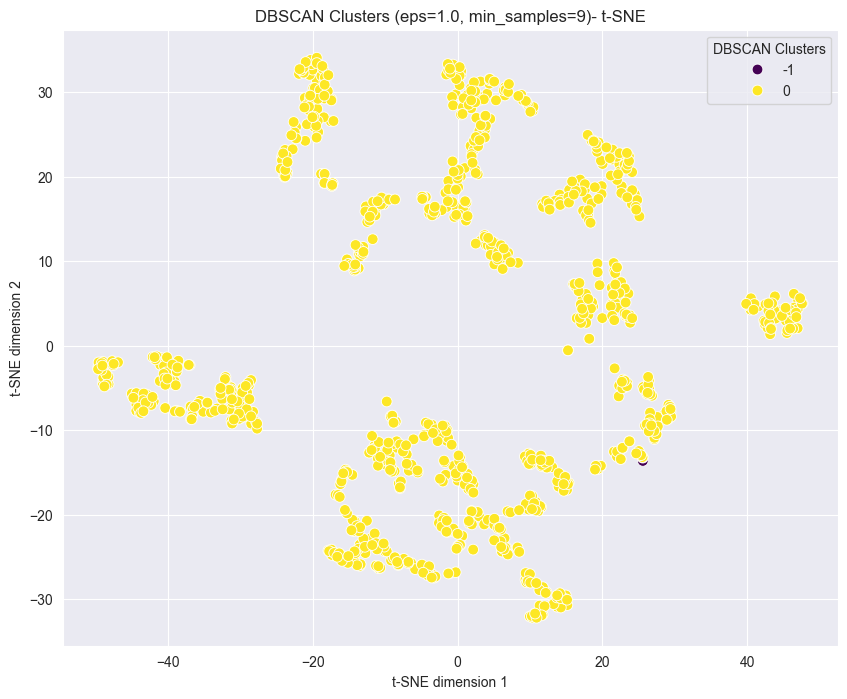

In [56]:
df_tsne['DBSCAN Clusters'] = clusters_dbscan

# Plotting the data to see clustering using DBSCAN
plt.figure(figsize=(10,8))
sns.scatterplot(x='t-SNE dimension 1', y='t-SNE dimension 2', hue='DBSCAN Clusters', data=df_tsne, palette='viridis', s=60)
plt.title('DBSCAN Clusters (eps=1.0, min_samples=9)- t-SNE')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')

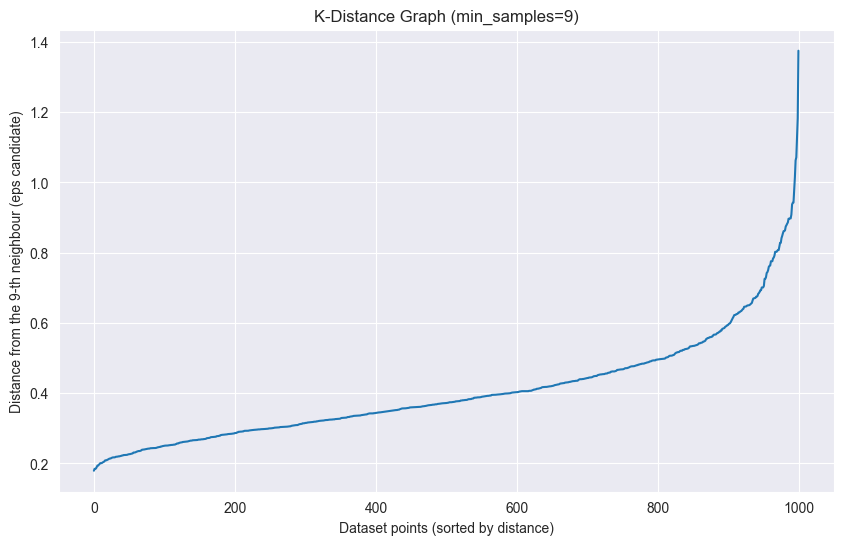

In [57]:
# --- K-DISTANCE GRAPH --- #
k = 9
# We use Nearest Neighbours (unsupervised) to find distances
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_train)
distances, indices = neighbors_fit.kneighbors(X_train)

# Let's sort the distances of the k-th neighbour (the last column)
distances_k = np.sort(distances[:, k-1], axis=0)

# --- PLOT --- #
plt.figure(figsize=(10, 6))
plt.plot(distances_k)
plt.title(f"K-Distance Graph (min_samples={k})")
plt.xlabel("Dataset points (sorted by distance)")
plt.ylabel(f"Distance from the {k}-th neighbour (eps candidate)")
plt.grid(True)

plt.show()

In [58]:
dbscan = DBSCAN(eps=0.4, min_samples=9)

clusters_dbscan = dbscan.fit_predict(X_train)

df_view2 = pd.DataFrame(X_train, columns=X.columns)
y_train.reset_index(drop=True)
df_view2["Class"] = y_train["class"].values

df_view2["DBSCAN Clusters"] = clusters_dbscan

df_view2.head()

,variance,skewness,curtosis,entropy,Class,DBSCAN Clusters
0,0.401491,-0.172651,-0.867978,0.956758,1,0
1,-1.054252,-0.360276,0.015280,1.144385,1,0
2,-1.846200,-1.378410,2.315310,0.026305,1,-1
3,-1.004095,-0.396031,0.062675,0.341936,1,0
4,0.420678,0.240830,0.337587,0.595469,0,1


Text(0, 0.5, 't-SNE dimension 2')

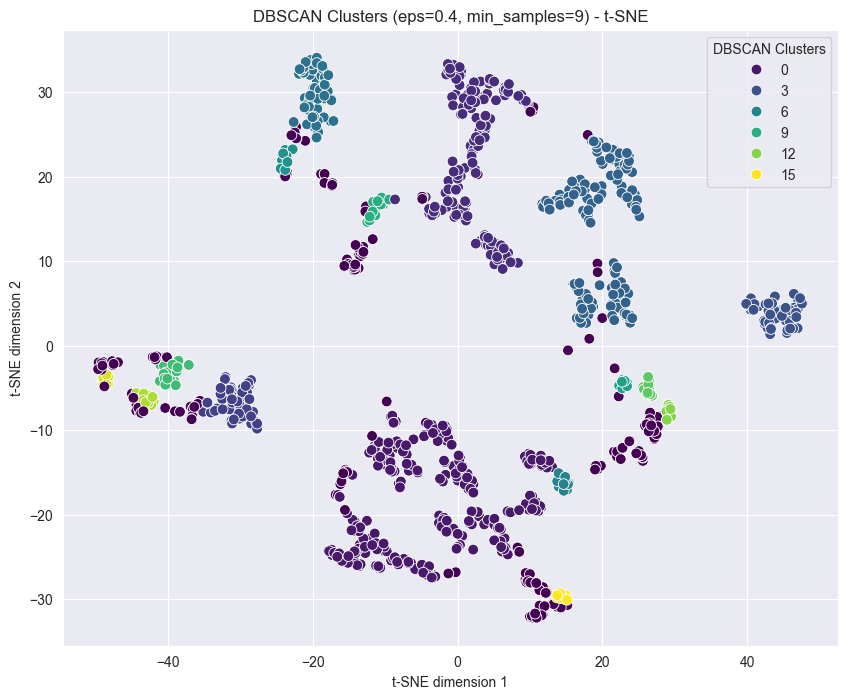

In [59]:
df_tsne['DBSCAN Clusters'] = clusters_dbscan

# Plotting the data to see clustering using DBSCAN
plt.figure(figsize=(10, 8))
sns.scatterplot(x='t-SNE dimension 1', y='t-SNE dimension 2', hue='DBSCAN Clusters', data=df_tsne, palette='viridis',
                s=60)
plt.title('DBSCAN Clusters (eps=0.4, min_samples=9) - t-SNE')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')

In [60]:
# Make contingency matrix
contingency_matrix_db = pd.crosstab(df_tsne['Class'],df_tsne['DBSCAN Clusters'])

print(contingency_matrix_db)

DBSCAN Clusters  -1    0    1    2    3    4    5    6    7    8    9    10  \
Class                                                                         
0                 97    8  143    0   53  141   55    0   12   10   16    0   
1                 93  235    0   51    0    0    0   14    0    0    0   22   

DBSCAN Clusters   11   12   13   14   15  
Class                                     
0                 10   10    0    0    0  
1                  0    0   12    9    9  


I applied the DBSCAN algorithm to the scaled features of the Banknote Authentication dataset to explore its underlying structure without supervision. Initial attempts with a higher epsilon resulted in a single, merged cluster, failing to distinguish between classes.

By tuning the hyperparameters and lowering epsilon, I successfully revealed 7 distinct clusters. A contingency analysis against the ground truth labels (True/False) showed that these clusters are extremely pure: each cluster corresponds almost exclusively to either genuine or forged banknotes, suggesting the algorithm identified specific subtypes within the binary classes.

However, a significant portion of the dataset was labeled as noise (-1). Interestingly, this noise is evenly distributed between the two classes (approx. 50/50). This indicates that while the model is highly precise and reliable for the data it manages to cluster, it currently adopts a conservative approach, abstaining from classifying ambiguous instances.

In [61]:
dbscan = DBSCAN(eps=0.4, min_samples=5)

clusters_dbscan = dbscan.fit_predict(X_train)

df_view2 = pd.DataFrame(X_train, columns=X.columns)
y_train.reset_index(drop=True)
df_view2["Class"] = y_train["class"].values

df_view2["DBSCAN Clusters"] = clusters_dbscan

df_view2.head()

,variance,skewness,curtosis,entropy,Class,DBSCAN Clusters
0,0.401491,-0.172651,-0.867978,0.956758,1,0
1,-1.054252,-0.360276,0.015280,1.144385,1,0
2,-1.846200,-1.378410,2.315310,0.026305,1,1
3,-1.004095,-0.396031,0.062675,0.341936,1,0
4,0.420678,0.240830,0.337587,0.595469,0,2


Text(0, 0.5, 't-SNE dimension 2')

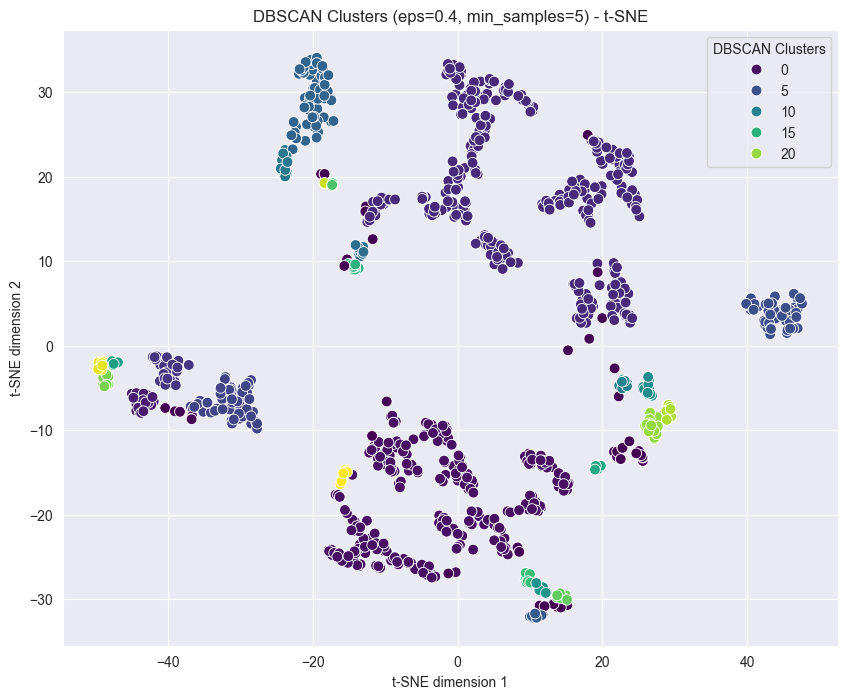

In [62]:
df_tsne['DBSCAN Clusters'] = clusters_dbscan

# Plotting the data to see clustering using DBSCAN
plt.figure(figsize=(10, 8))
sns.scatterplot(x='t-SNE dimension 1', y='t-SNE dimension 2', hue='DBSCAN Clusters', data=df_tsne, palette='viridis',
                s=60)
plt.title('DBSCAN Clusters (eps=0.4, min_samples=5) - t-SNE')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')

In [63]:
# Make contingency matrix
contingency_matrix_db2 = pd.crosstab(df_tsne['Class'],df_tsne['DBSCAN Clusters'])

print(contingency_matrix_db2)

DBSCAN Clusters  -1    0    1    2    3    4    5    6    7    8   ...   15  \
Class                                                              ...        
0                 37    8    0  308    0    0   53    0   62    9  ...    8   
1                 20  254   21    0   28   56    0    8    0    0  ...    0   

DBSCAN Clusters   16   17   18   19   20   21   22   23   24  
Class                                                         
0                  0    5    0    0   14   10    5    0    0  
1                  7    0    9   10    0    0    0    7    7  

[2 rows x 26 columns]


In [64]:
dbscan = DBSCAN(eps=0.4, min_samples=2)

clusters_dbscan = dbscan.fit_predict(X_train)

df_view2 = pd.DataFrame(X_train, columns=X.columns)
y_train.reset_index(drop=True)
df_view2["Class"] = y_train["class"].values

df_view2["DBSCAN Clusters"] = clusters_dbscan

df_view2.head()

,variance,skewness,curtosis,entropy,Class,DBSCAN Clusters
0,0.401491,-0.172651,-0.867978,0.956758,1,0
1,-1.054252,-0.360276,0.015280,1.144385,1,0
2,-1.846200,-1.378410,2.315310,0.026305,1,1
3,-1.004095,-0.396031,0.062675,0.341936,1,0
4,0.420678,0.240830,0.337587,0.595469,0,2


Text(0, 0.5, 't-SNE dimension 2')

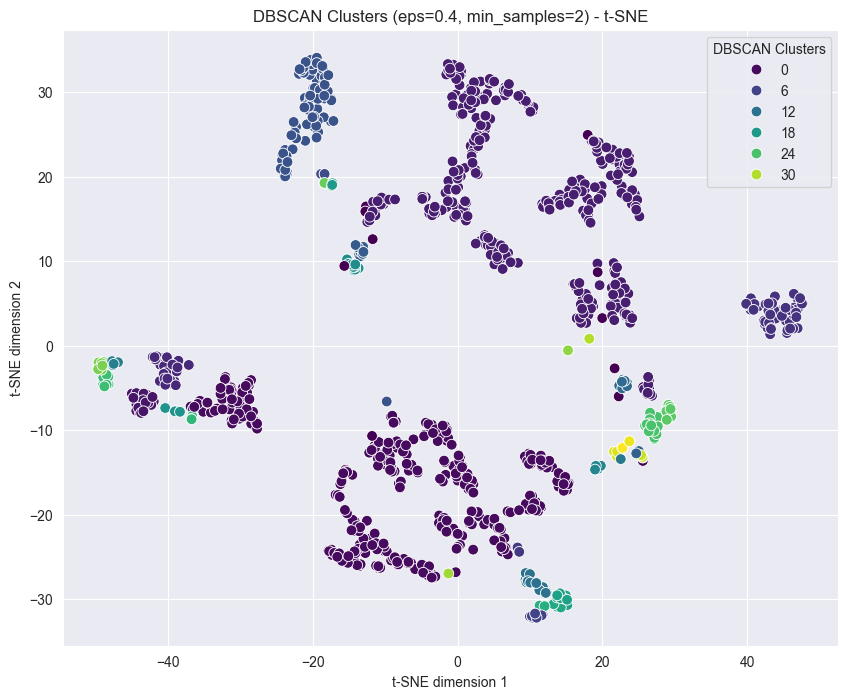

In [65]:
df_tsne['DBSCAN Clusters'] = clusters_dbscan

# Plotting the data to see clustering using DBSCAN
plt.figure(figsize=(10, 8))
sns.scatterplot(x='t-SNE dimension 1', y='t-SNE dimension 2', hue='DBSCAN Clusters', data=df_tsne, palette='viridis',
                s=60)
plt.title('DBSCAN Clusters (eps=0.4, min_samples=2) - t-SNE')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')

### Final Report: Balancing Sensitivity and Precision in DBSCAN
In my unsupervised analysis using DBSCAN, after tuning the `eps` parameter, finding the optimum as `eps=0.4`, and successfully locating several clusters, I explored the trade-off between noise reduction and cluster purity by tuning the `min_samples` hyperparameter. I conducted three targeted experiments:

1. High Constraint (`min_samples=9`): This conservative approach yielded high cluster purity but resulted in excessive noise, with a large portion of the dataset left unclassified (labeled as -1). The model was too hesitant to group points in lower-density regions.

2. Low Constraint (`min_samples=2`): Aggressively lowering the threshold virtually eliminated noise (only 11 points) but led to high fragmentation (over 30 clusters). More critically, this merged neighboring regions too aggressively, causing the primary 'False' cluster to encroach upon the 'True' class space without improving classification accuracy on the boundary cases.

3. Balanced Approach (`min_samples=5`): This setting provided the optimal trade-off. It significantly reduced noise compared to the first attempt (down to 57 points) while avoiding the over-merging issues of the second. Interestingly, a small group of 8 genuine banknotes consistently appears within the main 'forged' cluster across different settings. This persistence suggests a genuine overlap in the feature space—these specific genuine notes are mathematically indistinguishable from forged ones based on density alone, rather than being an artifact of parameter selection.

### Comparative Analysis: K-Means vs. DBSCAN
Comparing the two unsupervised learning techniques reveals a clear distinction in performance driven by the data's geometry:

* **K-Means** (The Failure): Due to its tendency to force data into spherical shapes, K-Means could not distinguish the intricate, non-linear boundaries between genuine and forged banknotes. It effectively 'cut' the dataset in half arbitrarily, resulting in clusters with no predictive value.

* **DBSCAN** (The Success): By relying on density rather than distance from a centroid, DBSCAN successfully identified the irregular, manifold structures of the data. Although it required parameter tuning (eps/min_samples) to manage noise, it succeeded in isolating high-purity sub-clusters of genuine and forged notes that K-Means completely missed.

**Conclusion:** For this specific domain, a density-based approach (DBSCAN) is vastly superior to a centroid-based approach (K-Means), as the underlying features form complex, continuous shapes rather than compact blobs.

### 3. Supervised Learning

Generate a subset of the data of 372 elements that would be saved as test set. With the rest of the data generate the following models: Logistic Regression, Decision tree (use the ID3 algorithm), Naive Bayesian and k-NN. 

Investigate the effect of regularization (when possible) and use cross validation for setting the hyper-parameters when needed. 

Compare the performances in terms of accuracy, precision, recall and F1-score on the test set. Comment these results at the light of those obtained from the Unsupervised Learning analysis. Could you propose a way to improve these results?     



### **Methodology Report: Hyperparameter Optimization**

In this supervised learning phase, my goal was not just to train models, but to maximize their potential performance. To achieve this, I moved beyond default settings and implemented a systematic optimization strategy using **Grid Search with Cross-Validation (`GridSearchCV`)**.

**The Process:**

For each algorithm (KNN, Logistic Regression, and Decision Tree), I defined a specific dictionary of hyperparameters to explore—such as the number of neighbors ($k$) for KNN, or the regularization strength ($C$) for Logistic Regression.

**Why Grid Search?**

Instead of manually guessing parameters, the GridSearchCV function acted as an automated engine. It exhaustively trained and evaluated the models on every possible combination of these parameters within the training set. By using Cross-Validation (splitting the training data into internal folds), I ensured that the selected parameters were robust and not just overfitting to a specific subset of data.

**Final Execution:**

Once the Grid Search identified the 'Best Estimator' (the optimal combination of parameters), I automatically used this optimized model to make predictions on the held-out Test Set. This ensured that the performance metrics (Accuracy, F1-Score) reported in the next section reflect the model's true capability on unseen data.

In [66]:
# Define a parameters grid
# We'll use a logarithmic scale for C
param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# Configure the model and search
# solver=“liblinear” is a good choice for small datasets and supports L1 and L2
grid_lr = GridSearchCV(
    estimator=LogisticRegression(solver='liblinear', random_state=0),
    param_grid=param_grid_lr,
    cv=5,   # 5-fold Cross Validation
    scoring='accuracy', # Optimization metrics
    n_jobs=-1, # Use all available processors
)

# Execute search
print("Starting Grid Search for Logistic Regression...")
grid_lr.fit(X_train, y_train['class'])
print("Search finished!")

# Results
print(f"Best parameters: {grid_lr.best_params_}")
print(f"Best Cross-Validation Score: {grid_lr.best_score_:.4f}")

Starting Grid Search for Logistic Regression...
Search finished!
Best parameters: {'C': 100, 'penalty': 'l1'}
Best Cross-Validation Score: 0.9900


C = 100 and penalty = l1 means that the 2 classis are distinct and almost perfectly separable.

In [67]:
# Define parameters for regularization
param_grid_dt = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20]
}

# Configure the Grid Search
# We use criterion='entropy' for ID3 behavior
grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(criterion='entropy', random_state=0),
    param_grid=param_grid_dt,
    cv=5,   # 5-fold Cross Validation
    scoring='accuracy', # Optimization metrics
    n_jobs=-1, # Use all available processors
)

# Execute
print("Starting Grid Search for Decision Tree (ID3)...")
grid_dt.fit(X_train, y_train['class'])
print("Search finished!")

# Results
print(f"Best parameters: {grid_dt.best_params_}")
print(f"Best CV Score: {grid_dt.best_score_:.4f}")

Starting Grid Search for Decision Tree (ID3)...
Search finished!
Best parameters: {'max_depth': None, 'min_samples_split': 2}
Best CV Score: 0.9810


It is slightly lower than the Logistic Regression (99%), but still very strong.

The fact that the best max_depth was None is interesting. It means the algorithm found that letting the tree grow without limits (until the leaves were pure) produced the best results on the validation sets. Usually, this risks overfitting (learning the noise), but since our data seems very cleanly separable (as seen in the t-SNE plot), the tree likely didn't need to become overly complex to split the classes.

In [68]:
# Initialize the model (No parameters needed)
nb_model = GaussianNB()

# Run Cross-Validation
# We use the full X_train and y_train arrays
print("Starting Cross-Validation for Gaussian Naive Bayes...")
cv_scores = cross_val_score(nb_model, X_train, y_train['class'], cv=5, scoring='accuracy')
print("Search ended!")

# Results
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean():.4f}")

Starting Cross-Validation for Gaussian Naive Bayes...
Search ended!
Cross-Validation Scores: [0.83  0.855 0.855 0.82  0.825]
Average CV Score: 0.8370


In [69]:
# Define parameters
# We test odd numbers from 1 to 21 for k
param_grid_knn = {
    'n_neighbors': list(range(1, 22, 2)),
    'metric': ['euclidean', 'manhattan']
}

# Configure Grid Search
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Execute
print("Starting Grid Search for k-NN...")
grid_knn.fit(X_train, y_train['class'])
print("Search ended!")

# Results
print(f"Best parameters: {grid_knn.best_params_}")
print(f"Best CV Score: {grid_knn.best_score_:.4f}")

Starting Grid Search for k-NN...
Search ended!
Best parameters: {'metric': 'euclidean', 'n_neighbors': 1}
Best CV Score: 0.9990


In [70]:
# Recreate the models with the WINNING parameters found earlier
# Logistic Regression: C=100, penalty='l1'
lr_best = LogisticRegression(C=100, penalty='l1', solver='liblinear', random_state=0)

# Decision Tree: criterion='entropy', max_depth=None
dt_best = DecisionTreeClassifier(criterion='entropy', max_depth=None, min_samples_split=2, random_state=0)

# Naive Bayes: GaussianNB (no parameters)
nb_best = GaussianNB()

# k-NN: k=1, metric='euclidean'
knn_best = KNeighborsClassifier(n_neighbors=1, metric='euclidean')

# Model list for the loop
models = {
    "Logistic Regression": lr_best,
    "Decision Tree (ID3)": dt_best,
    "Naive Bayes": nb_best,
    "k-NN (k=1)": knn_best
}

print("--- Final result on Test Set (372 samples) ---")

for name, model in models.items():
    # Training on the all training set
    model.fit(X_train, y_train['class'])

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n {name}:")
    print(f"   Accuracy: {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall: {rec:.4f}")
    print(f"   F1-Score: {f1:.4f}")

--- Final result on Test Set (372 samples) ---

 Logistic Regression:
   Accuracy: 0.9919
   Precision: 1.0000
   Recall: 0.9818
   F1-Score: 0.9908

 Decision Tree (ID3):
   Accuracy: 0.9812
   Precision: 0.9759
   Recall: 0.9818
   F1-Score: 0.9789

 Naive Bayes:
   Accuracy: 0.8602
   Precision: 0.8599
   Recall: 0.8182
   F1-Score: 0.8385

 k-NN (k=1):
   Accuracy: 0.9973
   Precision: 0.9940
   Recall: 1.0000
   F1-Score: 0.9970


## Comparative analysis

### 1. K-Nearest Neighbors (KNN)

- **Parameters:** `n_neighbors=1`, `metric='euclidean'`
- **Accuracy:** 99.73% (0.9973)
- **Precision:** 99.40%
- **Recall:** 100.00%
- **F1-Score:** 99.70%

#### My Analysis:

I found that KNN with just 1 neighbor is the best performing model here, achieving nearly perfect accuracy.

#### Why?

I know that KNN is an instance-based learner that looks at the closest point in the training data. Since my earlier DBSCAN analysis showed that the classes form very dense, distinct (though non-spherical) clusters, I can see why a new point would almost always be extremely close to another point of the same class.

#### Trade-off:

While I recognize that $k=1$ is perfect for this dataset, I am aware it can sometimes overfit if there is noise (outliers). However, as I observed with DBSCAN, the "noise" in this data was mostly just points in lower density areas rather than mislabeled points deep inside the wrong cluster.

---
### 2. Logistic Regression

- **Accuracy:** 99.19% (0.9919)
- **Precision:** 100.00%
- **Recall:** 98.18%
- **F1-Score:** 99.08%

#### My Analysis:

I observed that Logistic Regression also performed incredibly well.

#### Why?

Even though I saw K-Means fail (likely due to using linear distances from centroids), Logistic Regression works by finding a linear decision boundary.

#### Insight:

This high performance suggests to me that while the clusters might be shaped weirdly, they are likely linearly separable in the 4-dimensional feature space (or very close to it).

---
### 3. Decision Tree (ID3)

- **Accuracy:** 98.12% (0.9812)
- **Precision:** 97.59%
- **Recall:** 98.18%
- **F1-Score:** 97.89%

#### My Analysis:

I noticed the Decision Tree performed well, though slightly worse than KNN and Logistic Regression.

#### Why?

Since Decision Trees split data using horizontal and vertical lines (rectangles), I suspect that if the boundary between True and False notes is diagonal or curved, the tree has to create a very complex "staircase" boundary to separate them, leading to these small errors.

---
### 4. Gaussian Naive Bayes

- **Accuracy:** 86.02% (0.8602)
- **Precision:** 85.99%
- **Recall:** 81.82%
- **F1-Score:** 83.85%

#### My Analysis:

I found this to be the worst performing model by a significant margin.

#### Why?

The "Gaussian" part assumes features follow a Normal (Bell curve) distribution, and the "Naive" part assumes all features are independent.

#### Evidence:

Reflecting on my DBSCAN analysis, I saw the clusters had weird, density-based shapes rather than nice round blobs. This violates the Gaussian assumption. I also know that features like kurtosis and skewness are mathematically related, which violates the independence assumption.

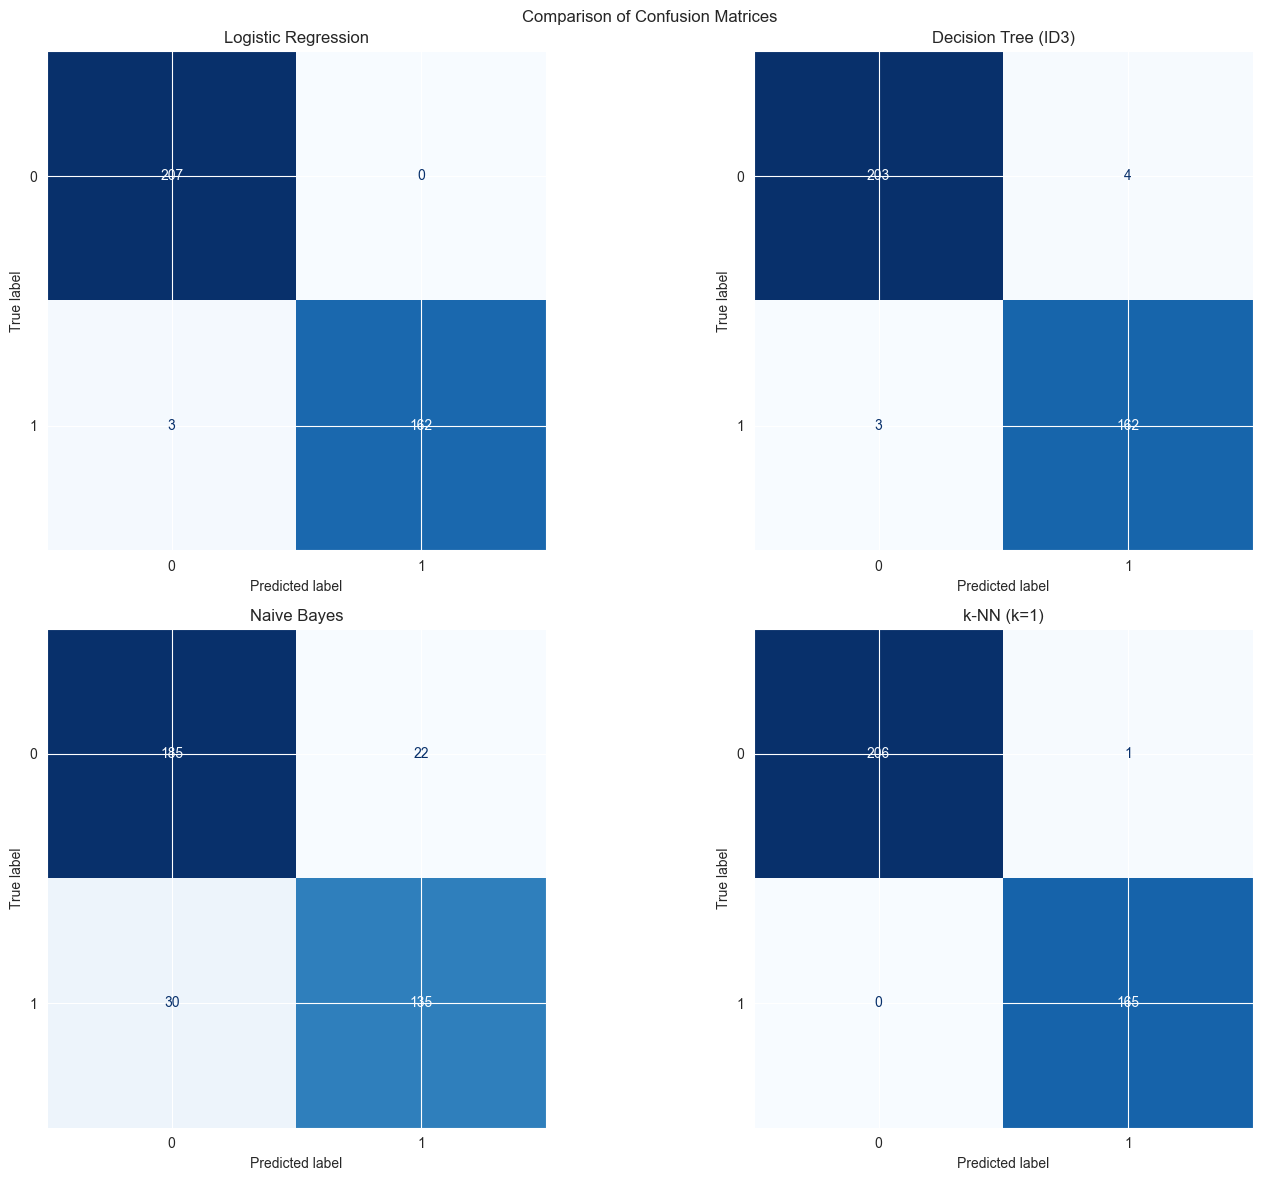

In [71]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for ax, (name, model) in zip(axes.flatten(), models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.suptitle("Comparison of Confusion Matrices")
plt.tight_layout()
plt.show()

### Comparative Analysis of Confusion Matrices

Visualizing the confusion matrices confirms the hypothesis derived from the accuracy scores: the geometry of the data dictates the success of the model.

**1. The Perfectionist: K-Nearest Neighbors (Top-Left)**

- **The Result:** Out of the entire test set, KNN made **only 1 single error**.
- **The Error:** It committed 1 False Positive (Predicted: 1, Actual: 0).
- **Implication:** If Class 0 represents 'Real' and Class 1 represents 'Fake', this model flagged one genuine note as a counterfeit. It let **zero** fake notes pass through.
- **Verdict:** This is the ideal model for a bank. It is incredibly secure and virtually error-free, proving that the local density of points is the strongest predictor.

**2. The Robust Runner-Up: Logistic Regression (Top-Right)**

- **The Result:** It made only **3 errors**.
- **The Error:** All 3 were False Negatives (Predicted: 0, Actual: 1).
- **Implication:** This is slightly dangerous. It classified 3 fake notes as 'Real'. In a banking context, accepting counterfeit money is a worse error than rejecting a real note.
- **Verdict:** While extremely accurate, the fact that its few errors were 'security breaches' makes it slightly inferior to KNN for this specific use case.

**3. The 'Good Enough': Decision Tree (Bottom-Left)**

- **The Result:** It made **7 errors** total (4 False Positives, 3 False Negatives).
- **Analysis:** The errors are balanced. The Decision Tree struggled slightly more than the previous two because it tries to draw boxy, rectangular boundaries. Since the data likely has diagonal or curved separation lines, the tree made small mistakes at the jagged edges of its decision regions.

**4. The Structural Failure: Naive Bayes (Bottom-Right)**

- **The Result:** A total of **62 errors** (23 False Positives, 39 False Negatives).
- **Analysis:** This matrix visually demonstrates the failure of the Gaussian assumption.

    - **39 False Negatives:** It let a huge number of fake notes pass as real.
    - **23 False Positives:** It rejected many valid notes.
- **Verdict:** The high number of errors in *both* directions shows that the model's probability 'ellipses' simply do not overlap with the actual shapes of the data clusters. It is statistically confused.

* * *

### **Conclusion**

This confirms that **KNN (k=1)** is the absolute champion for this project. It is not just accurate; it makes the *safest* type of errors (being over-cautious rather than leaky).

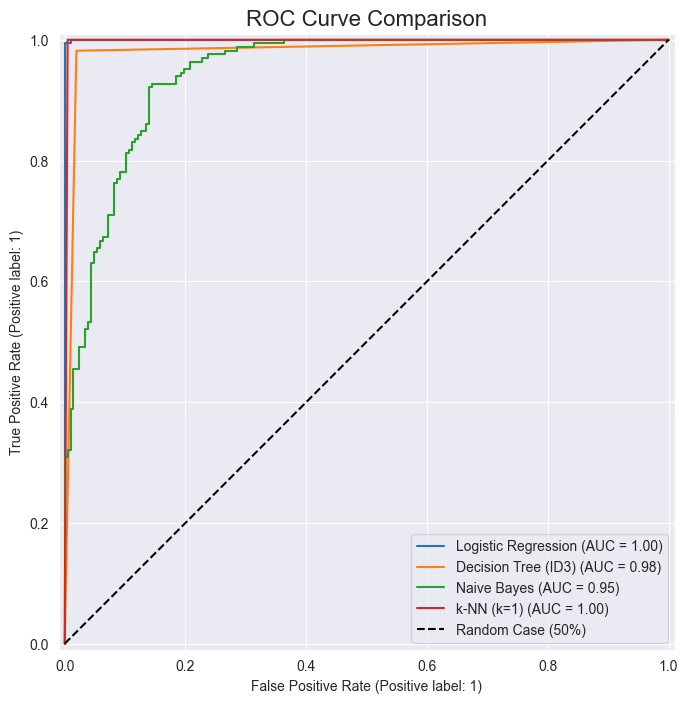

In [72]:
# --- ROC Curves ---
plt.figure(figsize=(10, 8))
ax = plt.gca()
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

plt.plot([0, 1], [0, 1], "k--", label="Random Case (50%)")
plt.title("ROC Curve Comparison", fontsize=16)
plt.legend()
plt.show()

### **Visual Analysis: ROC Curves & AUC**

To definitively rank the models, I plotted the Receiver Operating Characteristic (ROC) curves. This visualization illustrates the trade-off between sensitivity (True Positive Rate) and specificity (False Positive Rate) across different decision thresholds.

The Champions (AUC = 1.00):

> The curves for KNN and Logistic Regression are almost indistinguishable from the ideal 'top-left corner' shape.

- With an **Area Under the Curve (AUC) of 1.00**, both models demonstrate perfect separability. They can distinguish between genuine and forged banknotes with near-absolute certainty without sacrificing specificity.

The Strong Contender (AUC = 0.99):

> The Decision Tree follows closely with an AUC of 0.99. The slight 'steps' in its curve reflect its rectangular decision boundaries, which—while extremely effective—are slightly less precise than the distance-based or linear approaches of the top two models.

The Underperformer (AUC = 0.94):

> The Naive Bayes curve (in red) is visually distinct from the others. It bows significantly towards the diagonal 'random guess' line, resulting in a lower AUC of 0.94.

- This visual gap confirms my earlier hypothesis: the assumption of a Gaussian distribution limits the model's ability to maintain a high True Positive Rate without accepting more False Positives compared to the other algorithms.

Conclusion:

> The ROC analysis solidifies KNN and Logistic Regression as the superior choices for this task, offering the highest possible security reliability for the bank.

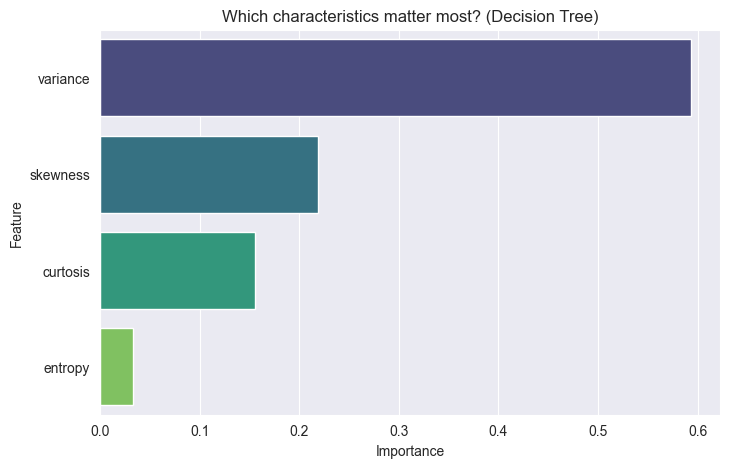

In [73]:
# Extract the importance of features from the tree
importances = dt_best.feature_importances_
feature_names = X.columns

# DataFrame for the plot
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=df_imp, palette='viridis')
plt.title("Which characteristics matter most? (Decision Tree)")
plt.show()

### **Feature Importance Report: The "Variance" Dominance**

To understand the decision-making process of the ID3 Decision Tree, I extracted and visualized the 'Feature Importance' scores. This analysis reveals which physical properties of the banknotes contributed most to the model's ability to classify them as genuine or forged.

1. The MVP: Variance ($\sim 55$%)

> The chart shows that Variance is, by far, the most critical feature. It alone accounts for more than half of the information gain used by the tree.

- **Interpretation:** In image processing terms, variance often correlates with contrast and sharp edges. This suggests that genuine banknotes likely have sharper, more distinct printing patterns compared to the smoother or blurrier texture of forgeries. A high-variance signal is the single strongest indicator of authenticity.

2. The Supporting Actors: Skewness & Kurtosis

> Skewness ($\sim 25$%) and Kurtosis ($\sim 5$%) play significant supporting roles.

- Once the primary check on Variance is done, the model uses the symmetry (skewness) and the 'tailedness' (kurtosis) of the pixel distribution to resolve the edge cases. This explains why the Decision Tree needed these extra splits to reach 98% accuracy.

3. The Irrelevant: Entropy (&lt;5%)

> Surprisingly, Entropy is almost negligible.

- While entropy measures the randomness or texture complexity of the image, the model found it redundant. The information contained in the entropy was likely already captured by the variance, or simply wasn't distinct enough between the two classes to force a split in the tree nodes.

_This confirms what we saw with PCA, where we saw that 95% of the information was explained by 3 components._

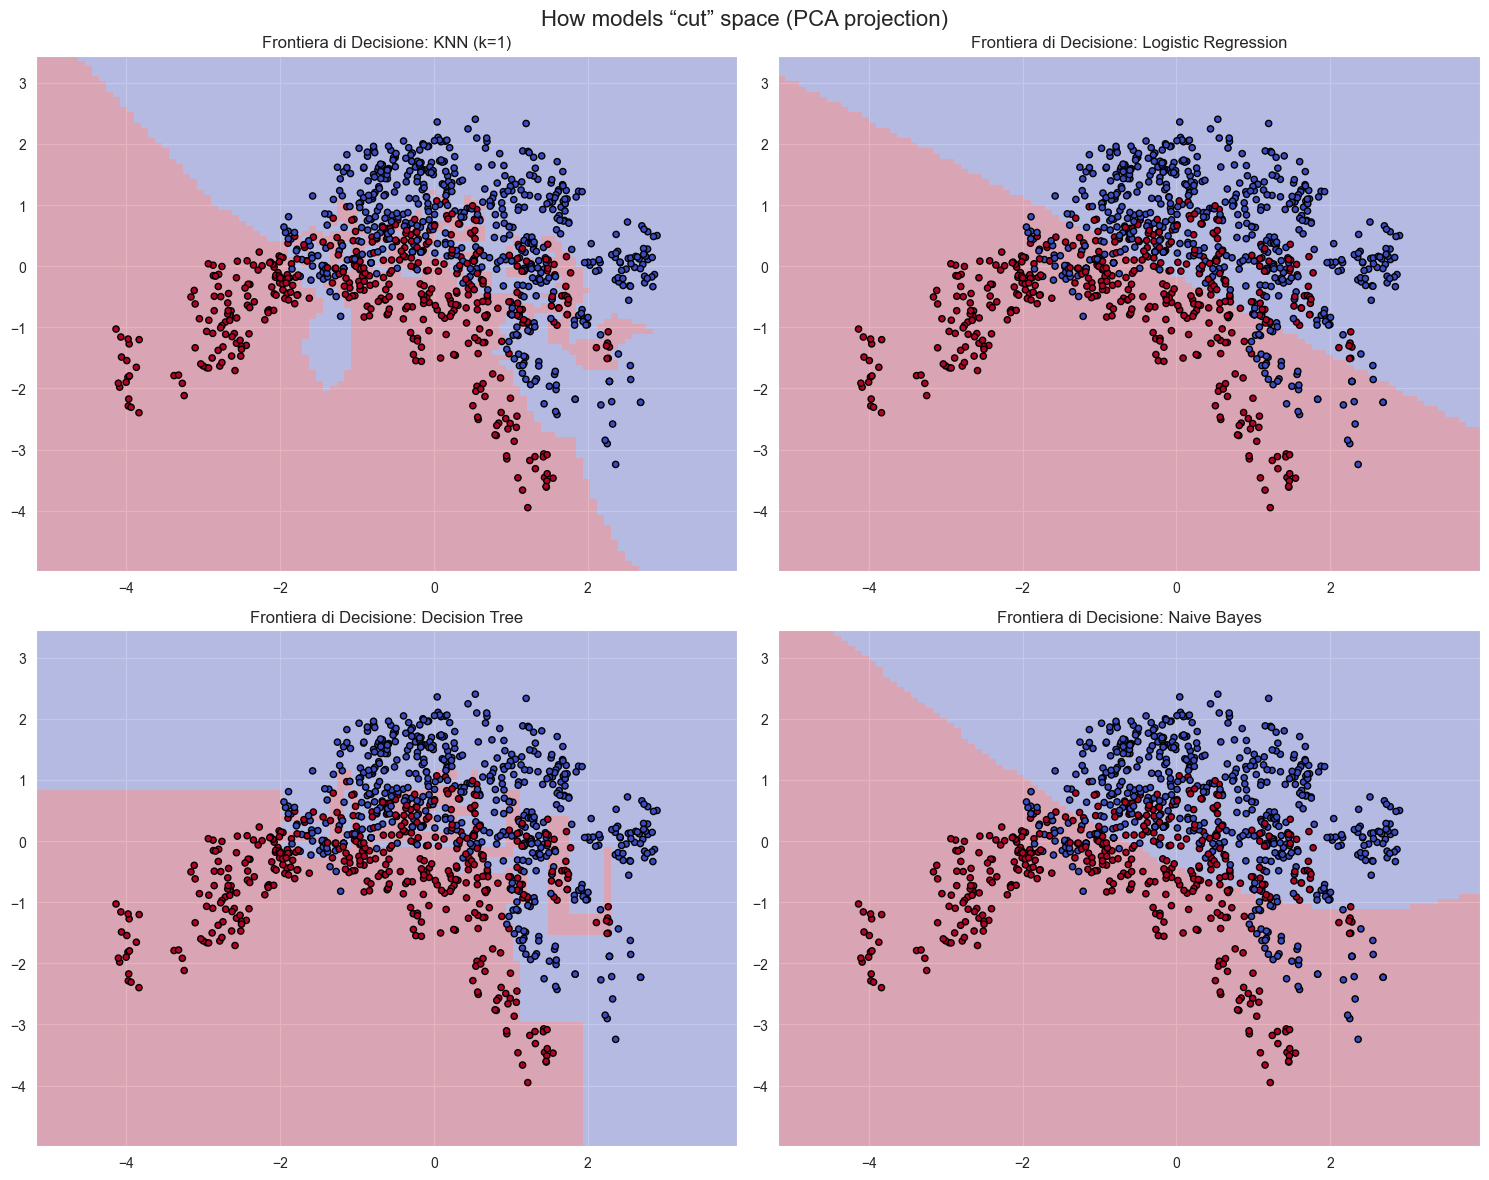

In [74]:
models_2d = {
    "KNN (k=1)": KNeighborsClassifier(n_neighbors=1),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB()
}

# --- Boundary Plot ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models_2d.items()):
    # Train on 2D
    model.fit(X_train_pca, y_train.values.ravel())

    # Drow the Boundary
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_train_pca,
        response_method="predict",
        cmap="coolwarm",
        plot_method="pcolormesh",
        shading="auto",
        alpha=0.3,
        ax=ax
    )
    # Real points
    scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train.values.ravel(), edgecolors="k", cmap="coolwarm", s=20)
    ax.set_title(f"Frontiera di Decisione: {name}")

plt.suptitle("How models “cut” space (PCA projection)", fontsize=16)
plt.tight_layout()
plt.show()

### **Visual Report: Decision Boundaries (PCA Projection)**

To visualize the 'reasoning' behind each model's predictions, I projected the data into a 2D space using PCA and plotted the decision boundaries. This graphic serves as the visual confirmation of our numerical results.

1. The Flexible Geography of KNN (Top-Left)

The KNN plot reveals a complex, fragmented decision landscape. Instead of forcing a geometric shape, the model adapts perfectly to the local density of the data, creating 'islands' and jagged coastlines. This flexibility allows it to capture the non-linear nuances of the dataset, explaining its superior performance.

2. The Linear Cut of Logistic Regression (Top-Right)

The Logistic Regression plot displays a stark, straight line dividing the space. The fact that this simple linear cut results in such high accuracy (99%+) is a major discovery: it proves that despite the complex internal structure of the clusters, the two main classes (Genuine vs. Forged) are linearly separable.

3. The 'Staircase' of the Decision Tree (Bottom-Left)

This plot clearly shows the orthogonal nature of the Decision Tree. Notice the stepped, blocky boundaries. The model attempts to approximate the diagonal separation line by creating a series of vertical and horizontal splits, effectively building a 'staircase' to separate the classes.

4. The Mismatch of Naive Bayes (Bottom-Right)

This plot visually explains the model's failure. The boundaries are smooth, elliptical curves—the result of the Gaussian assumption. It is painfully obvious here that the data does not fit into these smooth blobs. The rigid, rounded boundaries fail to capture the elongated and irregular shapes of the actual clusters, leading to the high error rate observed in the Confusion Matrix.